# Tutorial: `context_v3` initialization from raw data

This notebook presents a short, tutorial-style workflow focused only on the initialization step.

It shows how to:
- initialize a `WorkflowContext` from a raw-data directory using `context_v3`,
- inspect detected runs and configurations,
- inspect the dedicated reference stores filled during initialization,
- review warnings and basic sanity checks.

The idea is to keep the notebook focused on a single stage: **load and inspect**.


## 1. Environment setup

This first cell moves the notebook to the repository root and adds `src/` to the `PYTHONPATH`.
This is useful whether the notebook is launched from `notebooks/` or from the repository root.


In [1]:
from pathlib import Path
import os
import sys

%matplotlib inline

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

os.chdir(ROOT)
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"Repository root: {ROOT}")
print(f"Python path includes: {SRC}")


Repository root: /home/achennev/python/scarlet
Python path includes: /home/achennev/python/scarlet/src


## 2. Define the working paths

Here we define:
- the raw-data directory,
- the output directory used for converted files,
- the instrument name passed to the raw-data converter.


In [2]:
from scarlet.workflow.context import initialize_workflow_context_from_raw_directory, WorkflowContext

RAW_DIR = ROOT / "data" / "SANSLLB" / "raw_june"
OUTPUT_DIR = ROOT / "data" / "SANSLLB" / "out_june_v3"
INSTRUMENT_NAME = "sansllb"

RAW_DIR, OUTPUT_DIR


(PosixPath('/home/achennev/python/scarlet/data/SANSLLB/raw_june'),
 PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3'))

## 3. Initialize the `WorkflowContext`

This step scans the raw files, converts them to the SCARLET raw format,
detects runs, builds instrumental configurations, and stores everything in a `WorkflowContext` object.


In [3]:
w = initialize_workflow_context_from_raw_directory(
    RAW_DIR,
    instrument_name=INSTRUMENT_NAME,
    output_dir=OUTPUT_DIR,
    overwrite=True,
)

print(f"runs: {len(w.runs)}")
print(f"configurations: {len(w.configurations)}")
print(f"issues: {len(w.issues)}")
print(f"artifacts: {len(w.artifacts)}")
print(f"output_dir: {w.output_dir}")


runs: 200
configurations: 19
issues: 160
artifacts: 200
output_dir: /home/achennev/python/scarlet/data/SANSLLB/out_june_v3


In [4]:
# w = WorkflowContext(instrument_name=INSTRUMENT_NAME, output_dir=OUTPUT_DIR, root_dir=RAW_DIR)

## 7. Review initialization issues

Warnings collected during initialization are often useful when tuning the automatic classification.


In [5]:
# issue_rows = [
#     {
#         "level": issue.level,
#         "where": issue.where,
#         "key": issue.key,
#         "message": issue.message,
#     }
#     for issue in w.issues
# ]

# issue_rows[:20]


In [6]:
w.runs_table()

sample_name,config_id,mode,entity,thickness,transmission,file_path
H2O,config_1,scattering,water,1,,sans-llb2026n000902.nxs
H2O,config_2,scattering,water,1,,sans-llb2026n000903.nxs
H2O,config_3,scattering,water,1,,sans-llb2026n000904.nxs
H2O,config_4,scattering,water,1,,sans-llb2026n000905.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000908.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000909.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000910.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000911.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000912.nxs
EB,config_5,scattering,sample,0,,sans-llb2026n000913.nxs


In [7]:
w.write_runs_table_csv('runs_v3.csv',overwrite=True)

PosixPath('/home/achennev/python/scarlet/runs_v3.csv')

In [8]:
RUNS_TABLE = ROOT / "data" / "SANSLLB" / "raw" / "runs_v3_filtered.csv"
w.update_from_runs_table_csv(RUNS_TABLE)
w.compute_transmissions()
w.runs_table()

sample_name,config_id,mode,entity,thickness,transmission,file_path
Cd,config_9,transmission,dark,,,sans-llb2026n000974.nxs
EB,config_9,transmission,empty_beam,,,sans-llb2026n000975.nxs
AgBe,config_9,transmission,sample,1,0.795075,sans-llb2026n000976.nxs
EC,config_9,transmission,empty_cell,,0.927014,sans-llb2026n000977.nxs
H2O,config_9,transmission,water,1,,sans-llb2026n000978.nxs
ludox_AM20,config_9,transmission,sample,1,0.571943,sans-llb2026n000979.nxs
ludox_SM30,config_9,transmission,sample,1,0.552543,sans-llb2026n000980.nxs
ludox_TM50,config_9,transmission,sample,1,0.606994,sans-llb2026n000981.nxs
Cd,config_9,scattering,dark,,,sans-llb2026n000982.nxs
EB,config_9,scattering,empty_beam,,,sans-llb2026n000983.nxs


In [9]:
w.configurations_table()

config_id,wavelength,sample_detector_distance,collimation_distance,last_aperture_to_sample_distance,aperture1,aperture2,notes
config_10,5.00051 A,detector0=2 m; detector1=0.809993 m; detector2=0.809993 m,3 m,1.6 m,slit x=0.06 m y=0.06 m,slit x=0.008 m y=0.008 m,
config_9,4.99971 A,detector0=8.00001 m; detector1=2.66667 m; detector2=2.66667 m,8 m,1.6 m,slit x=0.06 m y=0.06 m,slit x=0.008 m y=0.008 m,


In [10]:
w.attach_mask_bundles_from_output_dir()
w.mask_files

{'config_9': PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/mask_8m_viewer.nxs'),
 'config_10': PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/masks_2m_viewer.nxs')}

In [11]:
w.build_water_flatfield(config_id="config_10")
w.set_flatfield_source(config_id="config_9", source_config_id="config_10")

'config_10'

## Test Pipepline

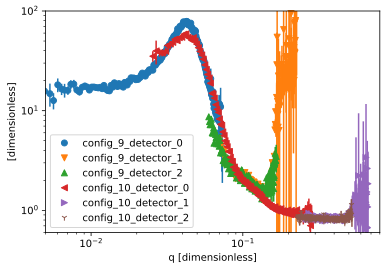

In [28]:
from scarlet.workflow.pipeline import ReductionPipeline, ReductionState
import plopp as pp

state = ReductionState(sample_name="ludox_SM30",config_id="config_9", workflow=w)
state2 = ReductionState(sample_name="ludox_SM30",config_id="config_10", workflow=w) 
pipe = ReductionPipeline().default()
pipe.run(state)
pipe.run(state2)

dic =  {}
for config_id, prefactor in [("config_9", 20), ("config_10", 1)]:
    for i in range(3):
        dic[f"{config_id}_detector_{i}"] = state.detectors[i] * prefactor if config_id == "config_9" else state2.detectors[i] * prefactor


pp.plot(dic,
    logx=True,
    logy=True,
    xmin=0.005,
    xmax=0.8,
    ymin=0.6,
    ymax=1e2,
)

# pp.plot(
#     {
#         "config_9": state.detectors[0] * 20,
#         "config_10": state2.detectors[0],
#     },
#     logx=True,
#     logy=True,
# )


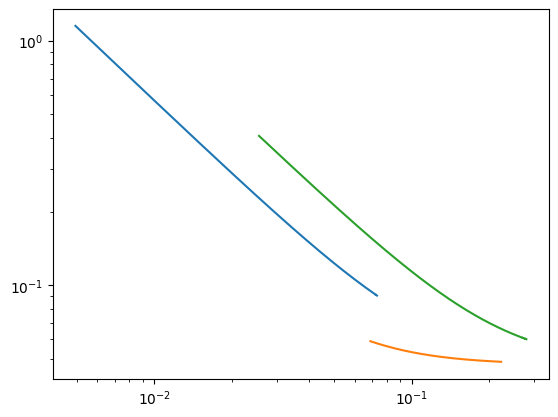

In [13]:
import matplotlib.pyplot as plt
plt.loglog(state.detectors[0].coords['q'], state.detectors[0].coords['q_error']/state.detectors[0].coords['q'], label="config_9")
plt.loglog(state.detectors[1].coords['q'], state.detectors[1].coords['q_error']/state.detectors[1].coords['q'], label="config_9_LA")


plt.loglog(state2.detectors[0].coords['q'], state2.detectors[0].coords['q_error']/state2.detectors[0].coords['q'], label="config_10")

In [14]:
state.detectors[0]

<scipp.DataArray>
Dimensions: Sizes[q:200, ]
Coordinates:
* counts                      int64  [dimensionless]  (q)  [5, 2, ..., 2, 1]
* q                         float64  [dimensionless]  (q)  [0.00493298, 0.00535319, ..., 0.0727626, 0.0733137]
* q_error                   float64  [dimensionless]  (q)  [0.00567309, 0.00567394, ..., 0.00663328, 0.00664687]
Data:
                            float64  [dimensionless]  (q)  [0.785991, 0.741141, ..., 0.213566, 0.185116]  [0.0307768, 0.0372319, ..., 0.00834472, 0.00826974]

In [15]:
from scarlet.workflow.pipeline import ReductionPipeline, ReductionState

state = ReductionState(sample_name="ludox_SM30",config_id="config_9", workflow=w)
state2 = ReductionState(sample_name="ludox_SM30",config_id="config_10", workflow=w) 
pipe = ReductionPipeline().with_azimuthal_text_output()
pipe.run(state)
pipe.run(state2)
print(state2.file_path)


/home/achennev/python/scarlet/data/SANSLLB/out_june_v3/sans-llb2026n001004.nxs


In [16]:
pipeline = ReductionPipeline.with_azimuthal_text_output()
for run in w.runs:
    if run.entity=="sample" and run.mode=="scattering":
        state = ReductionState(sample_name=run.sample_name, config_id=run.config_id,workflow=w)
        pipeline.run(state)